# ODM 2025 – Exercise Sheet 6: Black-box Service for Multi-objective Problem

## VPN Reminder

The black-box service is only available when **connected to the Uni Münster VPN**! Setup instructions can be found here: <https://www.uni-muenster.de/IT/en/services/kommunikation/vpn/index.html>

## General Setup

In [5]:
import requests
import numpy as np

In [6]:
class BlackBox:
    """
    This class implements a simple interface to the black-box service for the ODM course.
    """

    def __init__(self, token: int, endpoint: str = 'http://ls-stat-ml.uni-muenster.de:7300/'):
        self.endpoint = endpoint
        self.token = token

    def evaluate(self, objective: str, parameters: list) -> float:
        r = requests.post(url=self.endpoint + "compute/" + objective,
                          json={"parameters": [str(v) for v in parameters], "token": self.token})
        if r.status_code == 200:
            return r.json()
        else:
            print(parameters)
            raise ValueError(r)

    def evaluate_gradient(self, objective: str, parameters: list) -> list:
        r = requests.post(url=self.endpoint + "compute_gradient/" + objective,
                          json={"parameters": [str(v) for v in parameters], "token": self.token})
        return r.json()

Remember to change your group number!

In [7]:
# TODO: Change to your group number!
group_number = 11

bb = BlackBox(token = group_number)

## Evaluation Examples

With `bb.evaluate`, you can call the objective function (first argument) on any (two-dimensional) numerical vector (second argument):

In [8]:
opt1 = [0.0] * 30
opt1[0] += 0.42
opt1[1] -= 0.42

bb.evaluate("Function2", opt1), bb.evaluate("Function3", opt1)

(-306.9, 60.0495456)

In [9]:
opt2 = [1.0] * 30

bb.evaluate("Function2", opt2), bb.evaluate("Function3", opt2)

(-232.23317303903505, 1.1)

With `bb.evaluate_gradient`, you get the gradient of the objective function instead:

In [10]:
grad = bb.evaluate_gradient("Function2", [0.33, 0.44])
grad

[-37.2316894976521, -51.36205235078961]

The permutation-based problem `Function6` can be called like this:

In [11]:
initial_solution = bb.evaluate("Function6", list(range(0,20)))
initial_solution

3498.9338431451583

In [12]:
random_solution = bb.evaluate("Function6", np.random.permutation(20))
random_solution

3001.1896760651557

The multi-objective problem `Function7` can be called like this:

In [13]:
random_solution = bb.evaluate("Function7", np.random.choice([0,1], 30, replace = True))
random_solution

[9029.963521123685, 8646.15911983488]

To optimize using `pymoo`, first install the `pymoo` library:

In [14]:
!pip install pymoo


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


To use the API with `pymoo`, we need to perform a little setup:

In [15]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.hux import HalfUniformCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.optimize import minimize
from pymoo.termination import get_termination

class BinaryBiObjectiveProblem(Problem):

    def __init__(self):
        super().__init__(n_var=30, 
                         n_obj=2, 
                         n_constr=0, 
                         type_var=np.bool_)

    def _evaluate(self, X, out, *args, **kwargs):            
            n_individuals = X.shape[0]
            F = np.zeros((n_individuals, self.n_obj))

            for i, individual in enumerate(X):
                parameters = [int(x is True) for x in individual.tolist()]
                y = bb.evaluate("Function7", parameters)

                F[i, 0] = y[0]
                F[i, 1] = y[1]
                            
            out["F"] = F

Run default NSGA-II configuration. Please also explore other mutation and crossover operators, population sizes, number of generations (below) and other EMOAs!

In [16]:
algorithm = NSGA2(
    pop_size=100,
    # Binary-specific operators
    sampling=BinaryRandomSampling(),
    crossover=HalfUniformCrossover(),
    mutation=BitflipMutation(),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 100) # Stop after 100 generations

problem = BinaryBiObjectiveProblem()

# Optimize
res = minimize(problem,
               algorithm,
               termination,
               seed=42,
               verbose=False)

Print some solution details:

Total number of solutions found: 100

Non-Dominated Solutions (Bit String | F1 | F2):
000000000000000000000000000000 | 8987 | 9777
101111111111111111111111111111 | 9106 | 6641
000101010101010101010101001010 | 9042 | 8307
100000000000000000000000000000 | 8988 | 9772
000000100000001010001000010010 | 9012 | 9099
000000000100000000000000000000 | 8991 | 9664
001010101010101010111101010110 | 9054 | 7973
001010101010101010101101010110 | 9050 | 8084
001111111111111111111111111110 | 9101 | 6752
101111111111111111111101011110 | 9093 | 6969
101011101111110101110101011110 | 9072 | 7523
101111111111111111111111111110 | 9101 | 6747
001111111111111111111111111111 | 9105 | 6647
100000000001000000000000000000 | 8992 | 9658
100000000010001000000000000000 | 8996 | 9545
000000000010100000000000000000 | 8996 | 9551
000101000101000000000000000000 | 9004 | 9325
100100101001000001010010010010 | 9026 | 8754
100101010101010101001001001010 | 9038 | 8415
000100100100010000000000001000 | 9008 | 9212
10010000001000

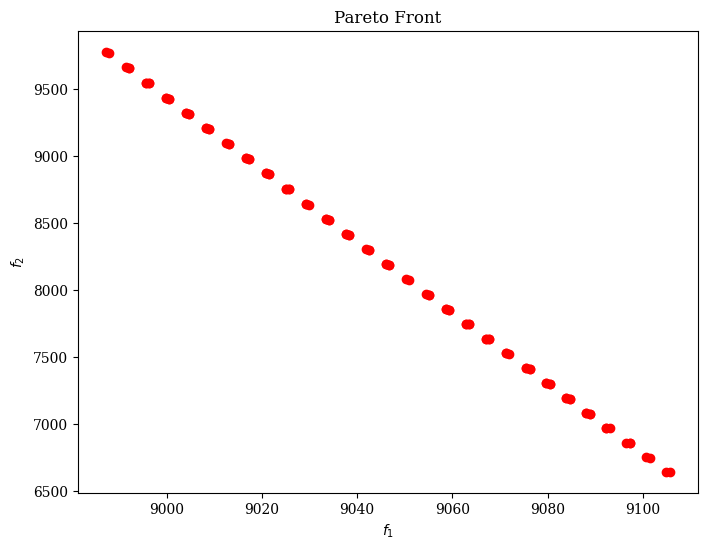

In [17]:
print(f"Total number of solutions found: {len(res.X)}")

# The Pareto-optimal solutions (bit strings)
X = res.X.astype(int) 

# The objective values for these solutions
F = res.F

# Display the non-dominated solutions from the final population
print("\nNon-Dominated Solutions (Bit String | F1 | F2):")
for i in range(len(X)):
    print(f"{''.join(map(str, X[i]))} | {F[i, 0]:.0f} | {F[i, 1]:.0f}")

from pymoo.visualization.scatter import Scatter
plot = Scatter(title="Pareto Front") 
plot.add(F, color="red") 
plot.show()

Your turn! How do you compare different optimizers? How can you compute the achieved hypervolume? etc. pp. ;-)